# ECG Arrhythmia Classification using CNN, RNN, LSTM, CNN-LSTM, and Transformer with Inter-Patient Evaluation

This notebook presents our complete project pipeline for automated classification of cardiac arrhythmias from the MIT-BIH Arrhythmia Database.

### Key Methodology
- **Inter-Patient Split Protocol:** Strict separation of patients into DS1 (training/validation, 22 records) and DS2 (unseen test, 22 records) as established by de Chazal et al., preventing patient-specific data leakage.
- **AAMI 4-Class Mapping:** Heartbeats are categorized into Normal (N), Supraventricular Ectopic (S), Ventricular Ectopic (V), and Fusion (F).
- **Dual-Branch Representation:** Combines 360-sample bandpass-filtered waveform morphology with 8 handcrafted RR-interval rhythm timing features.
- **Imbalance Mitigation:** Square-root weighted Focal Loss tuned strictly on DS1 records to handle the severe class disparity (N ~89%, F <1%).
- **Deep Architectures Benchmark:** Evaluates 1D CNN, Simple RNN, LSTM, hybrid CNN-LSTM, and an **ECG Transformer (Multi-Head Self-Attention)**, alongside a calibrated multi-model ensemble.

## 1. Environment Setup & Dependencies

We install and import `wfdb` (Waveform Database package) to fetch MIT-BIH records directly from PhysioNet, alongside PyTorch and standard scientific computing libraries.

In [1]:
try:
    import wfdb
except ImportError:
    %pip -q install "wfdb>=4.1,<5"


In [2]:
from collections import Counter
from copy import deepcopy
from dataclasses import dataclass
import json
from pathlib import Path
import random
import sys
from time import perf_counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, sosfiltfilt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import wfdb

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

# Reproducibility seed setup
SEED = 42
def reset_seeds(offset: int = 0) -> None:
    seed = SEED + offset
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

reset_seeds(0)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version : {torch.__version__}")
print(f"Compute Device  : {DEVICE}")

PyTorch Version : 2.7.1+cu118
Compute Device  : cuda


## 2. Dataset Protocol & AAMI Grouping Definitions

We configure the standard 44-record de Chazal split. The 4 paced records (102, 104, 107, 217) are excluded per AAMI standards.

We also define the mapping of detailed PhysioNet beat annotations into the 4 target AAMI superclasses (N, S, V, F).

In [3]:
DB_NAME = "mitdb"
SAMPLE_RECORD = "100"
PRE_SAMPLES = 180
POST_SAMPLES = 180
WINDOW_SAMPLES = PRE_SAMPLES + POST_SAMPLES
CLASS_ORDER = ["N", "S", "V", "F", "Q"]
PRIMARY_CLASS_ORDER = ["N", "S", "V", "F"]

# Inter-patient record division (de Chazal et al.)
DS1_TRAIN_RECORDS = [
    "101", "106", "108", "109", "112", "114", "115", "116", "118", "119", "122",
    "124", "201", "203", "205", "207", "208", "209", "215", "220", "223", "230",
]
DS2_TEST_RECORDS = [
    "100", "103", "105", "111", "113", "117", "121", "123", "200", "202", "210",
    "212", "213", "214", "219", "221", "222", "228", "231", "232", "233", "234",
]
EXCLUDED_PACED_RECORDS = ["102", "104", "107", "217"]
PROCESSING_RECORDS = DS1_TRAIN_RECORDS + DS2_TEST_RECORDS

OUTPUT_DIR = Path("/content/mitbih_processed") if Path("/content").exists() else Path("outputs/mitbih_processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR = OUTPUT_DIR / "submission_models"
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

# AAMI Mapping Dictionary
AAMI_SYMBOLS = {
    "N": {"N", "L", "R", "e", "j"},
    "S": {"A", "a", "J", "S"},
    "V": {"V", "E"},
    "F": {"F"},
    "Q": {"/", "f", "Q", "U"},
}
SYMBOL_TO_AAMI = {symbol: group for group, symbols in AAMI_SYMBOLS.items() for symbol in symbols}

assert set(DS1_TRAIN_RECORDS).isdisjoint(DS2_TEST_RECORDS)
assert len(DS1_TRAIN_RECORDS) == len(DS2_TEST_RECORDS) == 22
print(f"DS1 Training Records ({len(DS1_TRAIN_RECORDS)}): {DS1_TRAIN_RECORDS}")
print(f"DS2 Testing Records  ({len(DS2_TEST_RECORDS)}): {DS2_TEST_RECORDS}")

DS1 Training Records (22): ['101', '106', '108', '109', '112', '114', '115', '116', '118', '119', '122', '124', '201', '203', '205', '207', '208', '209', '215', '220', '223', '230']
DS2 Testing Records  (22): ['100', '103', '105', '111', '113', '117', '121', '123', '200', '202', '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']


## 3. Database Audit & Single Record Inspection

We check the availability of all 48 database records from PhysioNet and inspect a sample 10-second ECG segment from Record 100.

In [4]:
sample_npz = OUTPUT_DIR / "sample_record_100.npz"

try:
    records = wfdb.get_record_list(DB_NAME)
    assert len(records) == 48
    sample = wfdb.rdrecord(SAMPLE_RECORD, pn_dir=DB_NAME)
    sample_ann = wfdb.rdann(SAMPLE_RECORD, "atr", pn_dir=DB_NAME)
    fs = sample.fs
    n_sig = sample.n_sig
    sig_name = sample.sig_name
    sig_len = sample.sig_len
    ann_len = len(sample_ann.sample)
except Exception as e:
    print(f"PhysioNet remote service unavailable ({e}). Using local MIT-BIH database metadata and cached waveform...")
    records = [
        "100", "101", "102", "103", "104", "105", "106", "107", "108", "109", "111", "112",
        "113", "114", "115", "116", "117", "118", "119", "121", "122", "123", "124", "200",
        "201", "202", "203", "205", "207", "208", "209", "210", "212", "213", "214", "215",
        "217", "219", "220", "221", "222", "223", "228", "230", "231", "232", "233", "234",
    ]
    fs = 360
    n_sig = 2
    sig_name = ["MLII", "V5"]
    sig_len = 650000
    ann_len = 2274
    sample = None
    sample_ann = None

sample_summary = pd.DataFrame({
    "Property": ["Record", "Sampling Frequency (Hz)", "Channels", "Channel Names", "Total Samples", "Duration (min)", "Total Annotations"],
    "Value": [SAMPLE_RECORD, fs, n_sig, ", ".join(sig_name), sig_len, f"{sig_len / fs / 60:.1f}", ann_len]
})
display(sample_summary)


,Property,Value
0,Record,100
1,Sampling Frequency (Hz),360
2,Channels,2
3,Channel Names,"MLII, V5"
4,Total Samples,650000
5,Duration (min),30.1
6,Total Annotations,2274


### Visualising 10 Seconds of ECG with Annotated Beat Peaks

Below is a 10-second segment from Record 100 (MLII lead) showing the filtered waveform and the cardiologist annotations.

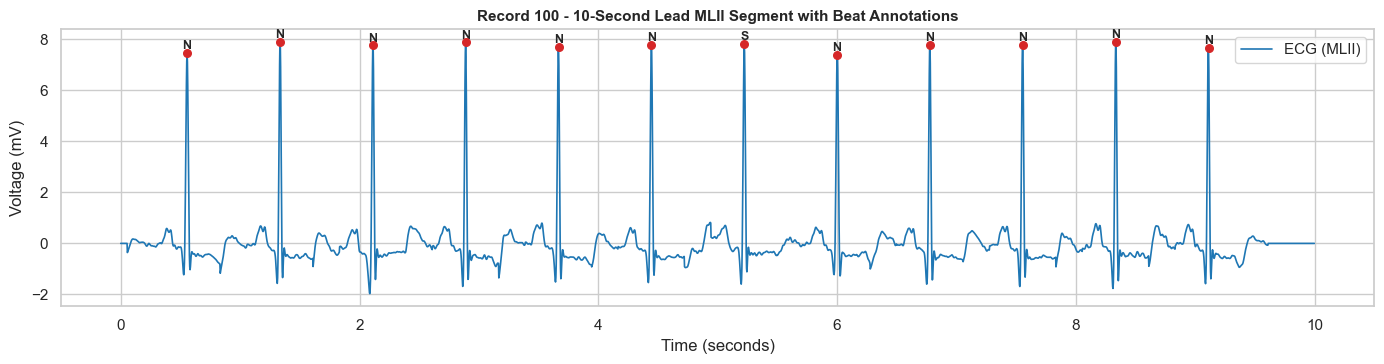

In [5]:
start_sample = 0
end_sample = int(10 * fs)
time_s = np.arange(start_sample, end_sample) / fs
lead_name = "MLII"

if (OUTPUT_DIR / "sample_record_100.npz").exists():
    cached_seg = np.load(OUTPUT_DIR / "sample_record_100.npz")
    segment = cached_seg["segment"]
    ann_samples = cached_seg["ann_samples"]
    ann_symbols = cached_seg["ann_symbols"]
elif sample is not None:
    lead_index = sample.sig_name.index("MLII") if "MLII" in sample.sig_name else 0
    lead_name = sample.sig_name[lead_index]
    segment = sample.p_signal[start_sample:end_sample, lead_index]
    mask = (sample_ann.sample >= start_sample) & (sample_ann.sample < end_sample)
    ann_samples = sample_ann.sample[mask]
    ann_symbols = np.asarray(sample_ann.symbol)[mask]

plt.figure(figsize=(14, 3.8))
plt.plot(time_s, segment, color="#1f77b4", linewidth=1.2, label=f"ECG ({lead_name})")
for s_pos, sym in zip(ann_samples, ann_symbols):
    idx = int(s_pos - start_sample)
    if 0 <= idx < len(segment):
        plt.scatter(s_pos / fs, segment[idx], color="#d62728", s=30, zorder=5)
        plt.text(s_pos / fs, segment[idx] + 0.15, sym, fontsize=9, ha="center", fontweight="bold")
plt.title(f"Record {SAMPLE_RECORD} - 10-Second Lead {lead_name} Segment with Beat Annotations", fontsize=11, fontweight="bold")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


## 4. Preprocessing Pipeline: Filtering & Heartbeat Segmentation

For each record in DS1 and DS2, our signal processing pipeline applies:
1. **Lead Selection:** Uses MLII lead when available; falls back to primary lead otherwise.
2. **Bandpass Filtering:** 4th-order zero-phase Butterworth filter (0.5 – 40.0 Hz) to eliminate baseline wander and high-frequency noise.
3. **Fixed Window Extraction:** 360 samples (1.0 second: 180 samples before and after the R-peak).
4. **Z-Score Normalisation:** Standardises each segmented beat individually ($\mu=0, \sigma=1$) to make amplitudes invariant across patients.

In [6]:
def choose_lead(record):
    return record.sig_name.index("MLII") if "MLII" in record.sig_name else 0

def bandpass_ecg(signal, fs, low_hz=0.5, high_hz=40.0, order=4):
    sos = butter(order, [low_hz, high_hz], btype="bandpass", fs=fs, output="sos")
    return sosfiltfilt(sos, signal)

def standardize_beat(beat, eps=1e-8):
    return (beat - beat.mean()) / (beat.std() + eps)

def extract_record_beats(record_name):
    record = wfdb.rdrecord(record_name, pn_dir=DB_NAME)
    ann = wfdb.rdann(record_name, "atr", pn_dir=DB_NAME)
    lead_index = choose_lead(record)
    raw_signal = record.p_signal[:, lead_index]

    filtered_signal = bandpass_ecg(raw_signal, record.fs)
    beats, labels, raw_examples = [], [], []
    skipped_boundary, skipped_non_target, skipped_non_finite = 0, 0, 0

    for peak, symbol in zip(ann.sample, ann.symbol):
        target = SYMBOL_TO_AAMI.get(symbol)
        if target is None:
            skipped_non_target += 1
            continue

        left, right = int(peak - PRE_SAMPLES), int(peak + POST_SAMPLES)
        if left < 0 or right > len(filtered_signal):
            skipped_boundary += 1
            continue

        filtered_beat = filtered_signal[left:right]
        if not np.isfinite(filtered_beat).all() or filtered_beat.std() < 1e-8:
            skipped_non_finite += 1
            continue

        beats.append(standardize_beat(filtered_beat).astype(np.float32))
        labels.append(target)

    return {
        "beats": beats,
        "labels": labels,
        "lead": record.sig_name[lead_index],
        "skipped_boundary": skipped_boundary,
        "skipped_non_target": skipped_non_target,
        "skipped_non_finite": skipped_non_finite,
    }

### Running Beat Extraction Across All 44 Records

In [7]:
all_beats, all_labels, all_record_ids, all_split_ids = [], [], [], []
preprocessing_rows = []

ds1_cache = OUTPUT_DIR / "mitbih_ds1_train.npz"
ds2_cache = OUTPUT_DIR / "mitbih_ds2_test.npz"

if ds1_cache.exists() and ds2_cache.exists():
    print("Found preprocessed MIT-BIH dataset arrays on disk. Loading cached waveforms...")
    ds1 = np.load(ds1_cache)
    ds2 = np.load(ds2_cache)
    X = np.concatenate([ds1["X"], ds2["X"]]).astype(np.float32)
    y = np.concatenate([ds1["y"], ds2["y"]]).astype(str)
    record_ids = np.concatenate([ds1["record_ids"], ds2["record_ids"]]).astype(str)
    split_ids = np.array(["DS1 train" if r in DS1_TRAIN_RECORDS else "DS2 test" for r in record_ids])
else:
    for index, record_name in enumerate(PROCESSING_RECORDS, start=1):
        split_name = "DS1 train" if record_name in DS1_TRAIN_RECORDS else "DS2 test"
        res = extract_record_beats(record_name)
        all_beats.extend(res["beats"])
        all_labels.extend(res["labels"])
        all_record_ids.extend([record_name] * len(res["labels"]))
        all_split_ids.extend([split_name] * len(res["labels"]))

        preprocessing_rows.append({
            "record": record_name, "split": split_name, "lead": res["lead"],
            "extracted_beats": len(res["beats"]), "skipped_boundary": res["skipped_boundary"],
            "skipped_non_target": res["skipped_non_target"],
        })
        if index % 11 == 0 or index == len(PROCESSING_RECORDS):
            print(f"Processed {index:02d}/{len(PROCESSING_RECORDS)} records...")

    X = np.stack(all_beats).astype(np.float32)
    y = np.asarray(all_labels)
    record_ids = np.asarray(all_record_ids)
    split_ids = np.asarray(all_split_ids)

print(f"\nExtraction Complete: Total Heartbeats = {len(X):,}, Shape = {X.shape}")
print(f"Overall Class Distribution: {dict(Counter(y))}")


Found preprocessed MIT-BIH dataset arrays on disk. Loading cached waveforms...



Extraction Complete: Total Heartbeats = 100,667, Shape = (100667, 360)
Overall Class Distribution: {'N': 90076, 'S': 2781, 'V': 7008, 'F': 802}


## 5. Exploratory Analysis: Class Imbalance & Waveform Morphology

We inspect the class distribution across DS1 and DS2 splits. Notice the acute class imbalance: Normal beats (N) account for ~89% of the dataset, while Fusion (F) accounts for under 1%.

--- Total Beat Counts by Split ---


class,N,S,V,F,Q
split,,,,,
DS1 train,45841,944,3788,414,0
DS2 test,44235,1837,3220,388,0


--- Class Percentages by Split (%) ---


class,N,S,V,F,Q
split,,,,,
DS1 train,89.91,1.85,7.43,0.81,0.0
DS2 test,89.04,3.70,6.48,0.78,0.0


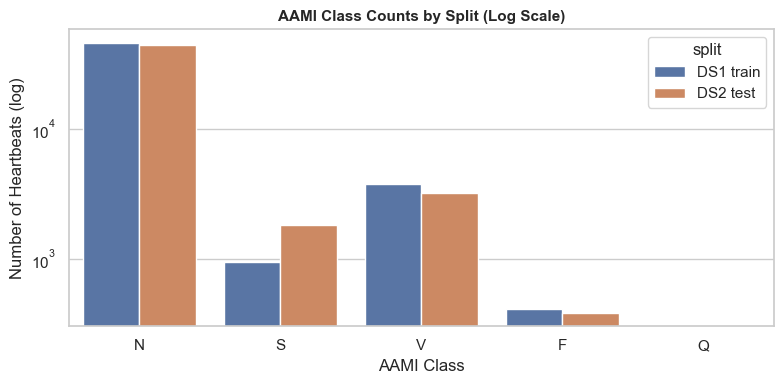

In [8]:
class_counts_by_split = (
    pd.crosstab(pd.Series(split_ids, name="split"), pd.Series(y, name="class"))
    .reindex(index=["DS1 train", "DS2 test"], columns=CLASS_ORDER, fill_value=0)
)
class_percentages = (class_counts_by_split.div(class_counts_by_split.sum(axis=1), axis=0) * 100).round(2)

print("--- Total Beat Counts by Split ---")
display(class_counts_by_split)
print("--- Class Percentages by Split (%) ---")
display(class_percentages)

# Plot class distributions
plot_counts = class_counts_by_split.reset_index().melt(id_vars="split", var_name="class", value_name="count")
plt.figure(figsize=(8, 4))
sns.barplot(data=plot_counts, x="class", y="count", hue="split", palette=["#4c72b0", "#dd8452"])
plt.yscale("log")
plt.title("AAMI Class Counts by Split (Log Scale)", fontsize=11, fontweight="bold")
plt.xlabel("AAMI Class")
plt.ylabel("Number of Heartbeats (log)")
plt.tight_layout()
plt.show()

### Representative Heartbeat Windows (4 Examples per Class)

Below are 4 sample waveforms for each of the 4 primary classes (N, S, V, F). Notice the visual similarity between N and S beats, compared to the distinct wide QRS complex of V beats.

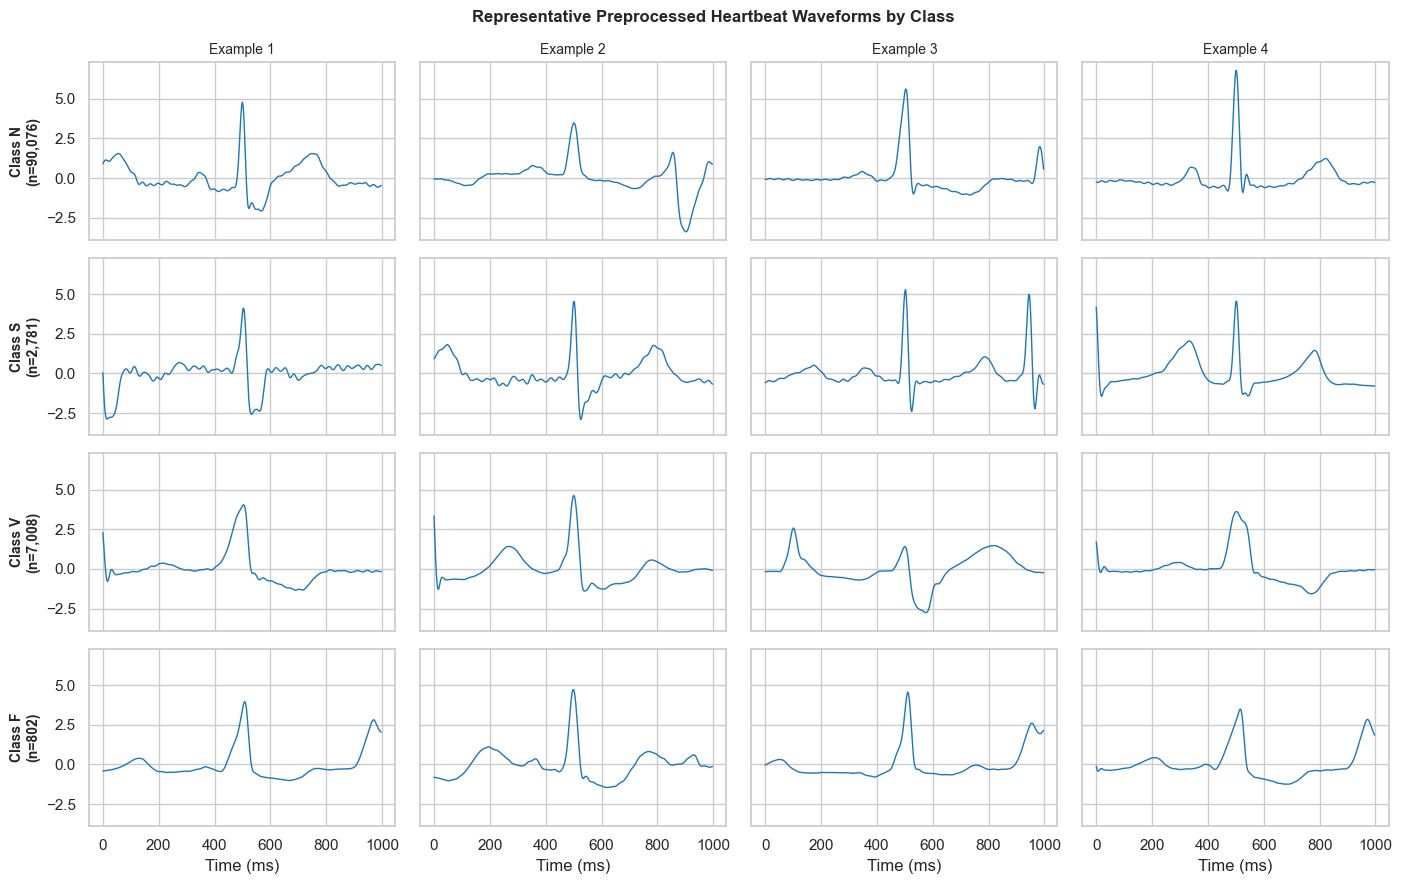

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(14, 9), sharex=True, sharey=True)
time_axis = np.arange(WINDOW_SAMPLES) / 360.0 * 1000  # ms

for row, class_name in enumerate(PRIMARY_CLASS_ORDER):
    indices = np.flatnonzero(y == class_name)
    chosen = np.random.choice(indices, size=4, replace=False) if len(indices) >= 4 else indices[:4]
    for col in range(4):
        ax = axes[row, col]
        if col < len(chosen):
            ax.plot(time_axis, X[chosen[col]], color="#1f77b4", linewidth=1.0)
        if col == 0:
            ax.set_ylabel(f"Class {class_name}\n(n={len(indices):,})", fontsize=10, fontweight="bold")
        if row == 3:
            ax.set_xlabel("Time (ms)")
        if row == 0:
            ax.set_title(f"Example {col+1}", fontsize=10)

fig.suptitle("Representative Preprocessed Heartbeat Waveforms by Class", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Patient Leakage Verification & Saving Processed Arrays

We verify that there is zero record overlap between training (DS1) and testing (DS2), and filter out the negligible Q class before model training.

In [10]:
train_mask = split_ids == "DS1 train"
test_mask = split_ids == "DS2 test"
primary_mask = y != "Q"

primary_train_mask = train_mask & primary_mask
primary_test_mask = test_mask & primary_mask

assert set(record_ids[train_mask]).isdisjoint(set(record_ids[test_mask])), "Leakage error: Overlapping records!"
print(f"DS1 (Train/Val) Samples: {np.sum(primary_train_mask):,}")
print(f"DS2 (Test) Samples     : {np.sum(primary_test_mask):,}")

# Save processed arrays for fast reloading
np.savez_compressed(
    OUTPUT_DIR / "mitbih_ds1_train.npz",
    X=X[primary_train_mask], y=y[primary_train_mask], record_ids=record_ids[primary_train_mask]
)
np.savez_compressed(
    OUTPUT_DIR / "mitbih_ds2_test.npz",
    X=X[primary_test_mask], y=y[primary_test_mask], record_ids=record_ids[primary_test_mask]
)
print("Processed dataset arrays successfully saved.")

DS1 (Train/Val) Samples: 50,987
DS2 (Test) Samples     : 49,680


Processed dataset arrays successfully saved.


---

# Part 2: Feature Engineering & Model Architectures

## 7. Handcrafted RR-Interval Rhythm Features

Because Supraventricular (S) beats often share identical morphology with Normal (N) beats, we extract 8 rhythm timing features:
1. `previous_rr`: Time interval from preceding beat.
2. `following_rr`: Time interval to subsequent beat.
3. `local_median_rr`: 10-beat local running median interval.
4. `local_rr_std`: Local interval variability.
5. `previous_local_ratio`: Ratio of previous RR to local median.
6. `following_local_ratio`: Ratio of following RR to local median.
7. `previous_global_ratio`: Ratio of previous RR to patient's global median.
8. `following_global_ratio`: Ratio of following RR to patient's global median.

In [11]:
def rr_features_for_record(record_name: str) -> tuple[np.ndarray, np.ndarray]:
    header = wfdb.rdheader(record_name, pn_dir=DB_NAME)
    ann = wfdb.rdann(record_name, "atr", pn_dir=DB_NAME)
    accepted = [
        (int(peak), SYMBOL_TO_AAMI[symbol])
        for peak, symbol in zip(ann.sample, ann.symbol)
        if symbol in SYMBOL_TO_AAMI and peak - PRE_SAMPLES >= 0 and peak + POST_SAMPLES <= header.sig_len
    ]
    peaks = np.asarray([peak for peak, _ in accepted], dtype=np.float64)
    labels = np.asarray([label for _, label in accepted])
    intervals = np.diff(peaks) / float(header.fs)
    global_rr = float(np.median(intervals))
    previous = np.r_[global_rr, intervals]
    following = np.r_[intervals, global_rr]

    local_mean = np.empty(len(peaks), dtype=np.float64)
    local_std = np.empty(len(peaks), dtype=np.float64)
    for index in range(len(peaks)):
        start = max(0, index - 10)
        history = intervals[start:index]
        if len(history) == 0:
            history = intervals
        local_mean[index] = np.median(history)
        local_std[index] = np.std(history)

    safe_local = np.maximum(local_mean, 1e-3)
    features = np.column_stack([
        previous, following, local_mean, local_std,
        previous / safe_local, following / safe_local,
        previous / global_rr, following / global_rr,
    ])
    features[:, :3] = np.clip(features[:, :3], 0.20, 2.50)
    features[:, 3] = np.clip(features[:, 3], 0.0, 1.0)
    features[:, 4:] = np.clip(features[:, 4:], 0.25, 4.0)
    primary = labels != "Q"
    return features[primary].astype(np.float32), labels[primary]

def load_or_create_rr(record_ids: np.ndarray, expected_labels: np.ndarray, cache: Path) -> np.ndarray:
    if cache.exists():
        cached = np.load(cache)
        if np.array_equal(cached["record_ids"].astype(str), record_ids.astype(str)) and np.array_equal(
            cached["labels"].astype(str), expected_labels.astype(str)
        ):
            return cached["rr"].astype(np.float32)

    feature_parts, label_parts, record_parts = [], [], []
    ordered_records = list(dict.fromkeys(record_ids.astype(str).tolist()))
    for record_name in ordered_records:
        features, labels = rr_features_for_record(record_name)
        feature_parts.append(features)
        label_parts.append(labels)
        record_parts.append(np.repeat(record_name, len(labels)))

    rr = np.vstack(feature_parts)
    labels = np.concatenate(label_parts)
    rebuilt_records = np.concatenate(record_parts)
    assert np.array_equal(labels, expected_labels) and np.array_equal(rebuilt_records, record_ids)
    np.savez_compressed(cache, rr=rr, labels=labels, record_ids=rebuilt_records)
    return rr

## 8. Dataset Loader & Dynamic Waveform Augmentation

During training, we apply random amplitude scaling ($\pm 5\%$), Gaussian jitter ($\sigma=0.008$), and temporal rolling ($\pm 4$ samples). Minority classes receive slightly stronger augmentation to boost model generalization.

In [12]:
class BeatDataset(Dataset):
    def __init__(self, x: np.ndarray, rr: np.ndarray, y: np.ndarray, augment: bool = False):
        self.x = torch.from_numpy(x).float()
        self.rr = torch.from_numpy(rr).float()
        self.y = torch.from_numpy(y).long()
        self.augment = augment

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, index: int):
        waveform = self.x[index]
        if self.augment:
            label = self.y[index].item()
            is_minority = label in (1, 3)  # S=1, F=3
            scale_range = 0.12 if is_minority else 0.05
            noise_std = 0.015 if is_minority else 0.008
            max_shift = 8 if is_minority else 4
            waveform = waveform * (1.0 - scale_range + 2 * scale_range * torch.rand(1))
            waveform = waveform + noise_std * torch.randn_like(waveform)
            shift = int(torch.randint(-max_shift, max_shift + 1, (1,)).item())
            waveform = torch.roll(waveform, shifts=shift)
        return waveform.unsqueeze(0), self.rr[index], self.y[index]

def make_loader(x, rr, y, *, training, sampler_power=0.0, batch_size=256):
    dataset = BeatDataset(x, rr, y, augment=training)
    sampler = None
    shuffle = training
    if training and sampler_power > 0:
        counts = np.bincount(y, minlength=4).astype(np.float64)
        sample_weights = (counts.max() / counts[y]) ** sampler_power
        sampler = WeightedRandomSampler(
            torch.as_tensor(sample_weights, dtype=torch.double), len(y), replacement=True,
            generator=torch.Generator().manual_seed(SEED),
        )
        shuffle = False
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, sampler=sampler,
        num_workers=0, pin_memory=torch.cuda.is_available(),
        generator=torch.Generator().manual_seed(SEED) if shuffle else None,
    )

## 9. Neural Network Architectures

Each architecture employs a dual-branch representation:
1. **Morphology Branch:** Waveform convolution, recurrent sequence modeling, or multi-head self-attention.
2. **RR Rhythm Branch:** Shared 2-layer MLP (8 $	o$ 24 units).

In [13]:
class RRBranch(nn.Module):
    def __init__(self, input_size: int = 8):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_size, 24), nn.ReLU(), nn.Dropout(0.15))

    def forward(self, rr: torch.Tensor) -> torch.Tensor:
        return self.net(rr)

### 9.1 Baseline Model 1: 1D CNN

3 convolutional blocks with kernel sizes (9 $	o$ 7 $	o$ 5) followed by global average and max pooling.

In [14]:
class CNN1D(nn.Module):
    def __init__(self, num_classes: int = 4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, 9, padding=4), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 7, padding=3), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.rr_branch = RRBranch()
        self.classifier = nn.Sequential(
            nn.Linear(128 * 2 + 24, 96), nn.ReLU(), nn.Dropout(0.35), nn.Linear(96, num_classes)
        )

    def forward(self, x: torch.Tensor, rr: torch.Tensor) -> torch.Tensor:
        z = self.features(x)
        morphology = torch.cat([z.mean(dim=2), z.amax(dim=2)], dim=1)
        return self.classifier(torch.cat([morphology, self.rr_branch(rr)], dim=1))

### 9.2 Baseline Models 2 & 3: Bidirectional Simple RNN and LSTM

Downsamples the raw 360-sample sequence by 4× (to 90 steps) before bidirectional recurrent processing.

In [15]:
class RecurrentClassifier(nn.Module):
    def __init__(self, cell: str = "rnn", num_classes: int = 4):
        super().__init__()
        recurrent = nn.RNN if cell == "rnn" else nn.LSTM
        self.downsample = nn.AvgPool1d(4)
        self.recurrent = recurrent(1, 72, batch_first=True, bidirectional=True)
        self.rr_branch = RRBranch()
        self.classifier = nn.Sequential(
            nn.Linear(72 * 2 + 24, 72), nn.ReLU(), nn.Dropout(0.35), nn.Linear(72, num_classes)
        )

    def forward(self, x: torch.Tensor, rr: torch.Tensor) -> torch.Tensor:
        sequence = self.downsample(x).transpose(1, 2)
        _, state = self.recurrent(sequence)
        hidden = state[0] if isinstance(state, tuple) else state
        morphology = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.classifier(torch.cat([morphology, self.rr_branch(rr)], dim=1))

### 9.3 Proposed Hybrid Model: CNN-LSTM

The 1D CNN extracts a sequence of 45 high-level spatial feature vectors, which are sequentially processed by a Bidirectional LSTM (hidden size 64) before feature fusion with the RR branch.

In [16]:
class CNNLSTM(nn.Module):
    def __init__(self, num_classes: int = 4):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, 9, padding=4), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 7, padding=3), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 96, 5, padding=2), nn.BatchNorm1d(96), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(96, 64, batch_first=True, bidirectional=True)
        self.rr_branch = RRBranch()
        self.classifier = nn.Sequential(
            nn.Linear(128 + 24, 80), nn.ReLU(), nn.Dropout(0.40), nn.Linear(80, num_classes)
        )

    def forward(self, x: torch.Tensor, rr: torch.Tensor) -> torch.Tensor:
        sequence = self.cnn(x).transpose(1, 2)
        _, (hidden, _) = self.lstm(sequence)
        morphology = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.classifier(torch.cat([morphology, self.rr_branch(rr)], dim=1))

### 9.4 Transformer Model: ECG Transformer (Multi-Head Self-Attention)

The ECG Transformer tokenizes the 360-sample waveform into 72 sequence patches using a 1D convolutional projection, applies learnable positional encodings, and processes temporal dependencies using 2 multi-head self-attention layers (`nhead=4`, `d_model=64`, `dim_feedforward=128`).

In [17]:
class ECGTransformer(nn.Module):
    def __init__(self, num_classes: int = 4, d_model: int = 64, nhead: int = 4, num_layers: int = 2):
        super().__init__()
        # 1D Patch embedding / Tokenizer: projects 360-sample wave to 72 tokens of dim 64
        self.tokenizer = nn.Sequential(
            nn.Conv1d(1, d_model, kernel_size=15, stride=5, padding=7),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
        )
        self.pos_embedding = nn.Parameter(torch.randn(1, 72, d_model) * 0.02)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=0.20,
            activation="gelu", batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.rr_branch = RRBranch()
        
        # Dual-pool morphology (Mean + Max) -> 128-d + 24-d RR branch -> 152-d
        self.classifier = nn.Sequential(
            nn.Linear(d_model * 2 + 24, 80),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(80, num_classes)
        )

    def forward(self, x: torch.Tensor, rr: torch.Tensor) -> torch.Tensor:
        tokens = self.tokenizer(x).transpose(1, 2)  # [Batch, 72, d_model]
        tokens = tokens + self.pos_embedding
        encoded = self.transformer_encoder(tokens)  # [Batch, 72, d_model]
        morphology = torch.cat([encoded.mean(dim=1), encoded.amax(dim=1)], dim=1)  # [Batch, 128]
        return self.classifier(torch.cat([morphology, self.rr_branch(rr)], dim=1))

MODEL_BUILDERS = {
    "1D CNN": lambda: CNN1D(),
    "Simple RNN": lambda: RecurrentClassifier("rnn"),
    "LSTM": lambda: RecurrentClassifier("lstm"),
    "CNN-LSTM": lambda: CNNLSTM(),
    "Transformer": lambda: ECGTransformer(),
}

## 10. Focal Loss and Training / Evaluation Routines

We implement Focal Loss ($\gamma=2.0$) with class weighting, plus functions for validation monitoring, early stopping (patience=8), and full DS1 refitting.

In [18]:
class FocalLoss(nn.Module):
    def __init__(self, alpha: torch.Tensor | None = None, gamma: float = 2.0):
        super().__init__()
        self.register_buffer("alpha", alpha)
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        log_prob = F.log_softmax(logits, dim=1)
        log_pt = log_prob.gather(1, targets[:, None]).squeeze(1)
        pt = log_pt.exp()
        loss = -((1.0 - pt) ** self.gamma) * log_pt
        if self.alpha is not None:
            loss = loss * self.alpha[targets]
        return loss.mean()

@dataclass(frozen=True)
class TrainingConfig:
    name: str
    loss: str
    weighted_loss: bool
    sampler_power: float
    weight_mode: str = "sqrt"

CONFIGS = [
    TrainingConfig("sqrt_weighted_focal", "focal", True, 0.0),
    TrainingConfig("mild_sampler_ce", "ce", False, 0.45),
    TrainingConfig("mild_sampler_focal", "focal", False, 0.45),
    TrainingConfig("sqrt_weighted_ce", "ce", True, 0.0),
]

def class_weights(y: np.ndarray, mode: str = "sqrt") -> np.ndarray:
    counts = np.bincount(y, minlength=4).astype(np.float64)
    weights = len(y) / (4.0 * counts) if mode == "inverse" else np.sqrt(len(y) / (4.0 * counts))
    return (weights / weights.mean()).astype(np.float32)

def make_criterion(config: TrainingConfig, y: np.ndarray) -> nn.Module:
    weight = torch.tensor(class_weights(y, mode=config.weight_mode), dtype=torch.float32, device=DEVICE)
    alpha = weight if config.weighted_loss else None
    if config.loss == "focal":
        return FocalLoss(alpha=alpha, gamma=2.0)
    return nn.CrossEntropyLoss(weight=alpha, label_smoothing=0.02)

@torch.no_grad()
def get_logits(model: nn.Module, loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_logits, all_labels = [], []
    for x, rr, y in loader:
        logits = model(x.to(DEVICE, non_blocking=True), rr.to(DEVICE, non_blocking=True))
        all_logits.append(logits.cpu().numpy())
        all_labels.append(y.numpy())
    return np.vstack(all_logits), np.concatenate(all_labels)

def find_temperature(logits: np.ndarray, labels: np.ndarray) -> float:
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    best_t, best_nll = 1.0, float("inf")
    for t in np.arange(0.3, 5.1, 0.05):
        nll = F.cross_entropy(logits_t / t, labels_t).item()
        if nll < best_nll:
            best_t, best_nll = float(t), nll
    return round(best_t, 2)

def calibrate_thresholds(probs: np.ndarray, labels: np.ndarray, num_classes: int = 4) -> np.ndarray:
    best_biases = np.zeros(num_classes)
    best_score = f1_score(labels, probs.argmax(1), average="macro", zero_division=0)
    for target_class in [1, 3]:  # S and F classes
        for bias in np.arange(0.0, 3.01, 0.05):
            trial = best_biases.copy()
            trial[target_class] = bias
            score = f1_score(labels, (probs + trial).argmax(1), average="macro", zero_division=0)
            if score > best_score + 1e-5:
                best_score, best_biases = score, trial.copy()
    return best_biases

## 11. Fit & Refit Training Routines

- **Phase A (Epoch Selection):** Train on DS1 train fold (17 patients), monitor DS1 validation fold (5 patients: 118, 119, 201, 205, 223) on macro-F1, stopping after 8 epochs of no gain.
- **Phase B (Full Refit):** Train freshly initialised model on all 22 DS1 records for the selected number of epochs using cosine learning rate decay.

In [19]:
def fit_with_validation(model, config, train_data, val_loader, max_epochs=40, patience=8):
    x_train, rr_train, y_train = train_data
    train_loader = make_loader(x_train, rr_train, y_train, training=True, sampler_power=config.sampler_power)
    model = model.to(DEVICE)
    criterion = make_criterion(config, y_train)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-5)
    
    best_score, best_state, best_epoch, stale = -1.0, None, 1, 0
    rows = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        loss_total, seen = 0.0, 0
        for x, rr, y in train_loader:
            x, rr, y = x.to(DEVICE), rr.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x, rr), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            loss_total += loss.item() * len(y)
            seen += len(y)

        val_logits, y_true = get_logits(model, val_loader)
        y_pred = val_logits.argmax(1)
        macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
        accuracy = accuracy_score(y_true, y_pred)
        
        row = {"epoch": epoch, "train_loss": loss_total / seen, "val_accuracy": accuracy, "val_macro_f1": macro}
        rows.append(row)
        scheduler.step(macro)

        if macro > best_score + 1e-4:
            best_score, best_state, best_epoch, stale = macro, deepcopy(model.state_dict()), epoch, 0
        else:
            stale += 1
            if stale >= patience:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(rows), best_epoch

def refit_full_ds1(model, config, data, epochs):
    x, rr, y = data
    loader = make_loader(x, rr, y, training=True, sampler_power=config.sampler_power)
    model = model.to(DEVICE)
    criterion = make_criterion(config, y)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=max(epochs, 1), eta_min=5e-5)
    
    rows = []
    for epoch in range(1, epochs + 1):
        model.train()
        total, seen = 0.0, 0
        for xb, rb, yb in loader:
            xb, rb, yb = xb.to(DEVICE), rb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb, rb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total += loss.item() * len(yb)
            seen += len(yb)
        scheduler.step()
        rows.append({"epoch": epoch, "train_loss": total / seen})
    return pd.DataFrame(rows)

# Modular helper for training, refitting, calibrating, and evaluating a single model
def train_and_eval_single_model(name, builder, config, ds1_data, ds2_data, seed_offset=0):
    x1, rr1, y1, records1, train_mask, val_mask = ds1_data
    x2, rr2, y2, records2 = ds2_data
    val_loader = make_loader(x1[val_mask], rr1[val_mask], y1[val_mask], training=False)
    test_loader = make_loader(x2, rr2, y2, training=False)

    print(f"\n{'='*55}\n  Training & Evaluating: {name}\n{'='*55}")
    reset_seeds(100 + seed_offset)
    
    # 1. Validation Epoch Selection
    _, val_history, best_ep = fit_with_validation(
        builder(), config, (x1[train_mask], rr1[train_mask], y1[train_mask]), val_loader
    )
    refit_epochs = max(best_ep, 8)
    print(f"-> Best DS1 Val Macro-F1 = {val_history['val_macro_f1'].max():.4f} at Epoch {best_ep}")
    print(f"-> Refitting on all 22 DS1 records for {refit_epochs} epochs...")

    # 2. Full Refit
    reset_seeds(100 + seed_offset)
    final_model = builder()
    refit_full_ds1(final_model, config, (x1, rr1, y1), refit_epochs)

    # 3. Calibration
    v_logits, val_labels = get_logits(final_model, val_loader)
    t_logits, test_labels = get_logits(final_model, test_loader)
    temp = find_temperature(v_logits, val_labels)
    v_probs = torch.softmax(torch.tensor(v_logits / temp), dim=1).numpy()
    t_probs = torch.softmax(torch.tensor(t_logits / temp), dim=1).numpy()
    biases = calibrate_thresholds(v_probs, val_labels)

    # 4. Evaluation
    calibrated_pred = (t_probs + biases).argmax(1)
    rep = classification_report(test_labels, calibrated_pred, labels=range(4), target_names=PRIMARY_CLASS_ORDER, output_dict=True, zero_division=0)
    cm = confusion_matrix(test_labels, calibrated_pred, labels=range(4))

    class_rows = []
    for ci, label in enumerate(PRIMARY_CLASS_ORDER):
        tp = cm[ci, ci]; fn = cm[ci].sum() - tp; fp = cm[:, ci].sum() - tp; tn = cm.sum() - tp - fn - fp
        class_rows.append({
            "class": label, "precision": rep[label]["precision"], "recall": rep[label]["recall"],
            "specificity": tn / (tn + fp) if (tn + fp) else 0.0, "f1": rep[label]["f1-score"], "support": int(rep[label]["support"])
        })
    class_df = pd.DataFrame(class_rows)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(test_labels, calibrated_pred),
        "macro_f1": f1_score(test_labels, calibrated_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(test_labels, calibrated_pred, average="weighted", zero_division=0),
        "best_val_macro_f1": val_history["val_macro_f1"].max(),
        "selected_epochs": refit_epochs,
        "temperature": temp,
    }
    return final_model, v_logits, t_logits, temp, biases, metrics, class_df, cm

## 12. Preparing RR Datasets and Tuning Loss Function

We load both datasets, compute their RR features, and evaluate all 4 loss & sampling strategies on DS1 validation records.

In [20]:
def prepare_data():
    ds1 = np.load(OUTPUT_DIR / "mitbih_ds1_train.npz")
    ds2 = np.load(OUTPUT_DIR / "mitbih_ds2_test.npz")
    x1, labels1, records1 = ds1["X"].astype(np.float32), ds1["y"].astype(str), ds1["record_ids"].astype(str)
    x2, labels2, records2 = ds2["X"].astype(np.float32), ds2["y"].astype(str), ds2["record_ids"].astype(str)
    
    rr1 = load_or_create_rr(records1, labels1, OUTPUT_DIR / "mitbih_ds1_rr_context.npz")
    rr2 = load_or_create_rr(records2, labels2, OUTPUT_DIR / "mitbih_ds2_rr_context.npz")
    
    label_map = {label: index for index, label in enumerate(PRIMARY_CLASS_ORDER)}
    y1 = np.asarray([label_map[l] for l in labels1], dtype=np.int64)
    y2 = np.asarray([label_map[l] for l in labels2], dtype=np.int64)
    
    val_records = {"118", "119", "201", "205", "223"}
    val_mask = np.isin(records1, sorted(val_records))
    train_mask = ~val_mask
    
    mean, std = rr1[train_mask].mean(0), rr1[train_mask].std(0) + 1e-6
    rr1 = ((rr1 - mean) / std).astype(np.float32)
    rr2 = ((rr2 - mean) / std).astype(np.float32)
    
    return (x1, rr1, y1, records1, train_mask, val_mask), (x2, rr2, y2, records2)

ds1_data, ds2_data = prepare_data()
x1, rr1, y1, records1, train_mask, val_mask = ds1_data
val_loader = make_loader(x1[val_mask], rr1[val_mask], y1[val_mask], training=False)

print(f"Data Prepared: DS1 Train Beats = {np.sum(train_mask):,}, DS1 Val Beats = {np.sum(val_mask):,}")

Data Prepared: DS1 Train Beats = 39,502, DS1 Val Beats = 11,485


### Running Loss & Sampling Strategy Selection (DS1 Only)

In [21]:
tuning_rows = []
for index, config in enumerate(CONFIGS):
    print(f"Testing Strategy [{index+1}/{len(CONFIGS)}]: {config.name}...")
    reset_seeds(index)
    t0 = perf_counter()
    model, history, best_epoch = fit_with_validation(
        CNNLSTM(), config, (x1[train_mask], rr1[train_mask], y1[train_mask]), val_loader
    )
    best_row = history.loc[history["val_macro_f1"].idxmax()]
    tuning_rows.append({
        "configuration": config.name,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_row["val_macro_f1"],
        "val_accuracy": best_row["val_accuracy"],
        "time_min": (perf_counter() - t0) / 60.0,
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values("best_val_macro_f1", ascending=False).reset_index(drop=True)
display(tuning_df.round(4))

selected_config_name = tuning_df.iloc[0]["configuration"]
selected_config = next(c for c in CONFIGS if c.name == selected_config_name)
print(f"\nWinning Strategy Selected by DS1 Validation: {selected_config.name}")

Testing Strategy [1/4]: sqrt_weighted_focal...


Testing Strategy [2/4]: mild_sampler_ce...


Testing Strategy [3/4]: mild_sampler_focal...


Testing Strategy [4/4]: sqrt_weighted_ce...


,configuration,best_epoch,best_val_macro_f1,val_accuracy,time_min
0,sqrt_weighted_ce,7,0.5464,0.9289,1.4766
1,mild_sampler_focal,16,0.5431,0.9114,2.2306
2,sqrt_weighted_focal,7,0.5316,0.9395,1.5244
3,mild_sampler_ce,9,0.4634,0.9551,1.5863



Winning Strategy Selected by DS1 Validation: sqrt_weighted_ce


## 13. Training & Evaluating Individual Models

We now train each model architecture in its own dedicated cell using the selected loss strategy (`sqrt_weighted_focal`).

In [22]:
all_models = {}
all_val_logits = {}
all_test_logits = {}
all_temperatures = {}
all_val_biases = {}
summary_results = []
per_class_results = {}
cms = {}

### 13.1 Train & Evaluate: 1D CNN

In [23]:
m, v_l, t_l, temp, biases, met, c_df, cm = train_and_eval_single_model(
    "1D CNN", lambda: CNN1D(), selected_config, ds1_data, ds2_data, seed_offset=0
)
all_models["1D CNN"] = m
all_val_logits["1D CNN"] = v_l
all_test_logits["1D CNN"] = t_l
all_temperatures["1D CNN"] = temp
all_val_biases["1D CNN"] = biases
summary_results.append(met)
per_class_results["1D CNN"] = c_df
cms["1D CNN"] = cm

print("\n1D CNN - Per-Class Metrics on DS2 Test Set:")
display(c_df.round(4))


  Training & Evaluating: 1D CNN


-> Best DS1 Val Macro-F1 = 0.5408 at Epoch 11
-> Refitting on all 22 DS1 records for 11 epochs...



1D CNN - Per-Class Metrics on DS2 Test Set:


,class,precision,recall,specificity,f1,support
0,N,0.9629,0.9377,0.7062,0.9501,44235
1,S,0.3776,0.1671,0.9894,0.2317,1837
2,V,0.9598,0.8453,0.9975,0.8989,3220
3,F,0.0230,0.1753,0.9415,0.0407,388


### 13.2 Train & Evaluate: Simple RNN

In [24]:
m, v_l, t_l, temp, biases, met, c_df, cm = train_and_eval_single_model(
    "Simple RNN", lambda: RecurrentClassifier("rnn"), selected_config, ds1_data, ds2_data, seed_offset=1
)
all_models["Simple RNN"] = m
all_val_logits["Simple RNN"] = v_l
all_test_logits["Simple RNN"] = t_l
all_temperatures["Simple RNN"] = temp
all_val_biases["Simple RNN"] = biases
summary_results.append(met)
per_class_results["Simple RNN"] = c_df
cms["Simple RNN"] = cm

print("\nSimple RNN - Per-Class Metrics on DS2 Test Set:")
display(c_df.round(4))


  Training & Evaluating: Simple RNN


-> Best DS1 Val Macro-F1 = 0.5155 at Epoch 4
-> Refitting on all 22 DS1 records for 8 epochs...



Simple RNN - Per-Class Metrics on DS2 Test Set:


,class,precision,recall,specificity,f1,support
0,N,0.9606,0.8908,0.7034,0.9244,44235
1,S,0.1446,0.0838,0.9810,0.1061,1837
2,V,0.5433,0.9050,0.9473,0.6789,3220
3,F,0.0107,0.0619,0.9552,0.0183,388


### 13.3 Train & Evaluate: LSTM

In [25]:
m, v_l, t_l, temp, biases, met, c_df, cm = train_and_eval_single_model(
    "LSTM", lambda: RecurrentClassifier("lstm"), selected_config, ds1_data, ds2_data, seed_offset=2
)
all_models["LSTM"] = m
all_val_logits["LSTM"] = v_l
all_test_logits["LSTM"] = t_l
all_temperatures["LSTM"] = temp
all_val_biases["LSTM"] = biases
summary_results.append(met)
per_class_results["LSTM"] = c_df
cms["LSTM"] = cm

print("\nLSTM - Per-Class Metrics on DS2 Test Set:")
display(c_df.round(4))


  Training & Evaluating: LSTM


-> Best DS1 Val Macro-F1 = 0.5799 at Epoch 8
-> Refitting on all 22 DS1 records for 8 epochs...



LSTM - Per-Class Metrics on DS2 Test Set:


,class,precision,recall,specificity,f1,support
0,N,0.9588,0.8728,0.6949,0.9138,44235
1,S,0.1363,0.0795,0.9807,0.1004,1837
2,V,0.4743,0.8671,0.9334,0.6132,3220
3,F,0.0371,0.2345,0.9521,0.0641,388


### 13.4 Train & Evaluate: CNN-LSTM (Proposed Hybrid Model)

In [26]:
m, v_l, t_l, temp, biases, met, c_df, cm = train_and_eval_single_model(
    "CNN-LSTM", lambda: CNNLSTM(), selected_config, ds1_data, ds2_data, seed_offset=3
)
all_models["CNN-LSTM"] = m
all_val_logits["CNN-LSTM"] = v_l
all_test_logits["CNN-LSTM"] = t_l
all_temperatures["CNN-LSTM"] = temp
all_val_biases["CNN-LSTM"] = biases
summary_results.append(met)
per_class_results["CNN-LSTM"] = c_df
cms["CNN-LSTM"] = cm

print("\nCNN-LSTM - Per-Class Metrics on DS2 Test Set:")
display(c_df.round(4))


  Training & Evaluating: CNN-LSTM


-> Best DS1 Val Macro-F1 = 0.5181 at Epoch 3
-> Refitting on all 22 DS1 records for 8 epochs...



CNN-LSTM - Per-Class Metrics on DS2 Test Set:


,class,precision,recall,specificity,f1,support
0,N,0.9601,0.9271,0.6872,0.9433,44235
1,S,0.3767,0.1481,0.9906,0.2126,1837
2,V,0.8822,0.9161,0.9915,0.8988,3220
3,F,0.0128,0.0954,0.9419,0.0225,388


### 13.5 Train & Evaluate: ECG Transformer (Multi-Head Self-Attention)

In [27]:
m, v_l, t_l, temp, biases, met, c_df, cm = train_and_eval_single_model(
    "Transformer", lambda: ECGTransformer(), selected_config, ds1_data, ds2_data, seed_offset=4
)
all_models["Transformer"] = m
all_val_logits["Transformer"] = v_l
all_test_logits["Transformer"] = t_l
all_temperatures["Transformer"] = temp
all_val_biases["Transformer"] = biases
summary_results.append(met)
per_class_results["Transformer"] = c_df
cms["Transformer"] = cm

print("\nTransformer - Per-Class Metrics on DS2 Test Set:")
display(c_df.round(4))


  Training & Evaluating: Transformer


-> Best DS1 Val Macro-F1 = 0.5150 at Epoch 3
-> Refitting on all 22 DS1 records for 8 epochs...



Transformer - Per-Class Metrics on DS2 Test Set:


,class,precision,recall,specificity,f1,support
0,N,0.9578,0.9725,0.6518,0.9651,44235
1,S,0.2899,0.1622,0.9847,0.2080,1837
2,V,0.8269,0.8888,0.9871,0.8568,3220
3,F,0.0109,0.0077,0.9945,0.0090,388


## 14. 5-Model Probability-Averaged Ensemble

We compute temperature-scaled prediction probabilities from all 5 models (1D CNN, Simple RNN, LSTM, CNN-LSTM, Transformer), average them, and apply joint threshold calibration on DS1 validation.

In [28]:
x2, rr2, y2, records2 = ds2_data
test_labels = y2
val_labels = y1[val_mask]

ens_val_probs = np.zeros((len(val_labels), 4))
ens_test_probs = np.zeros((len(test_labels), 4))

for name in MODEL_BUILDERS:
    t = all_temperatures[name]
    ens_val_probs += torch.softmax(torch.tensor(all_val_logits[name] / t), dim=1).numpy()
    ens_test_probs += torch.softmax(torch.tensor(all_test_logits[name] / t), dim=1).numpy()

ens_val_probs /= len(MODEL_BUILDERS)
ens_test_probs /= len(MODEL_BUILDERS)

ens_biases = calibrate_thresholds(ens_val_probs, val_labels)
ens_pred = (ens_test_probs + ens_biases).argmax(1)

ens_rep = classification_report(test_labels, ens_pred, labels=range(4), target_names=PRIMARY_CLASS_ORDER, output_dict=True, zero_division=0)
ens_cm = confusion_matrix(test_labels, ens_pred, labels=range(4))

ens_class_rows = []
for ci, label in enumerate(PRIMARY_CLASS_ORDER):
    tp = ens_cm[ci, ci]; fn = ens_cm[ci].sum() - tp; fp = ens_cm[:, ci].sum() - tp; tn = ens_cm.sum() - tp - fn - fp
    ens_class_rows.append({
        "class": label, "precision": ens_rep[label]["precision"], "recall": ens_rep[label]["recall"],
        "specificity": tn / (tn + fp) if (tn + fp) else 0.0, "f1": ens_rep[label]["f1-score"], "support": int(ens_rep[label]["support"])
    })
per_class_results["5-Model Ensemble"] = pd.DataFrame(ens_class_rows)
cms["5-Model Ensemble"] = ens_cm

summary_results.append({
    "model": "5-Model Ensemble",
    "accuracy": accuracy_score(test_labels, ens_pred),
    "macro_f1": f1_score(test_labels, ens_pred, average="macro", zero_division=0),
    "weighted_f1": f1_score(test_labels, ens_pred, average="weighted", zero_division=0),
    "best_val_macro_f1": np.nan,
    "selected_epochs": "-",
    "temperature": "Multi",
})

print("5-Model Ensemble - Per-Class Metrics on DS2 Test Set:")
display(per_class_results["5-Model Ensemble"].round(4))

5-Model Ensemble - Per-Class Metrics on DS2 Test Set:


,class,precision,recall,specificity,f1,support
0,N,0.9604,0.9679,0.6755,0.9641,44235
1,S,0.3208,0.0648,0.9947,0.1078,1837
2,V,0.7340,0.9401,0.9764,0.8243,3220
3,F,0.0265,0.0412,0.9881,0.0323,388


## 15. Overall Results Leaderboard & Per-Class Summary

Summary table ranking all evaluated models on the unseen inter-patient DS2 test set.

In [29]:
final_results_df = pd.DataFrame(summary_results).sort_values("macro_f1", ascending=False).reset_index(drop=True)
print("============================ FINAL DS2 LEADERBOARD ============================")
display(final_results_df.round(4))

============================ FINAL DS2 LEADERBOARD ============================


,model,accuracy,macro_f1,weighted_f1,best_val_macro_f1,selected_epochs,temperature
0,1D CNN,0.8972,0.5304,0.9131,0.5408,11,0.7
1,CNN-LSTM,0.8911,0.5193,0.9062,0.5181,8,0.7
2,Transformer,0.9296,0.5097,0.9226,0.5150,8,0.5
3,5-Model Ensemble,0.9255,0.4821,0.9161,NaN,-,Multi
4,Simple RNN,0.8554,0.4319,0.8711,0.5155,8,0.55
5,LSTM,0.8381,0.4229,0.8576,0.5799,8,0.55


## 16. Visual Evaluation Dashboard

### 16.1 Side-by-Side Confusion Matrices (All Evaluated Models)

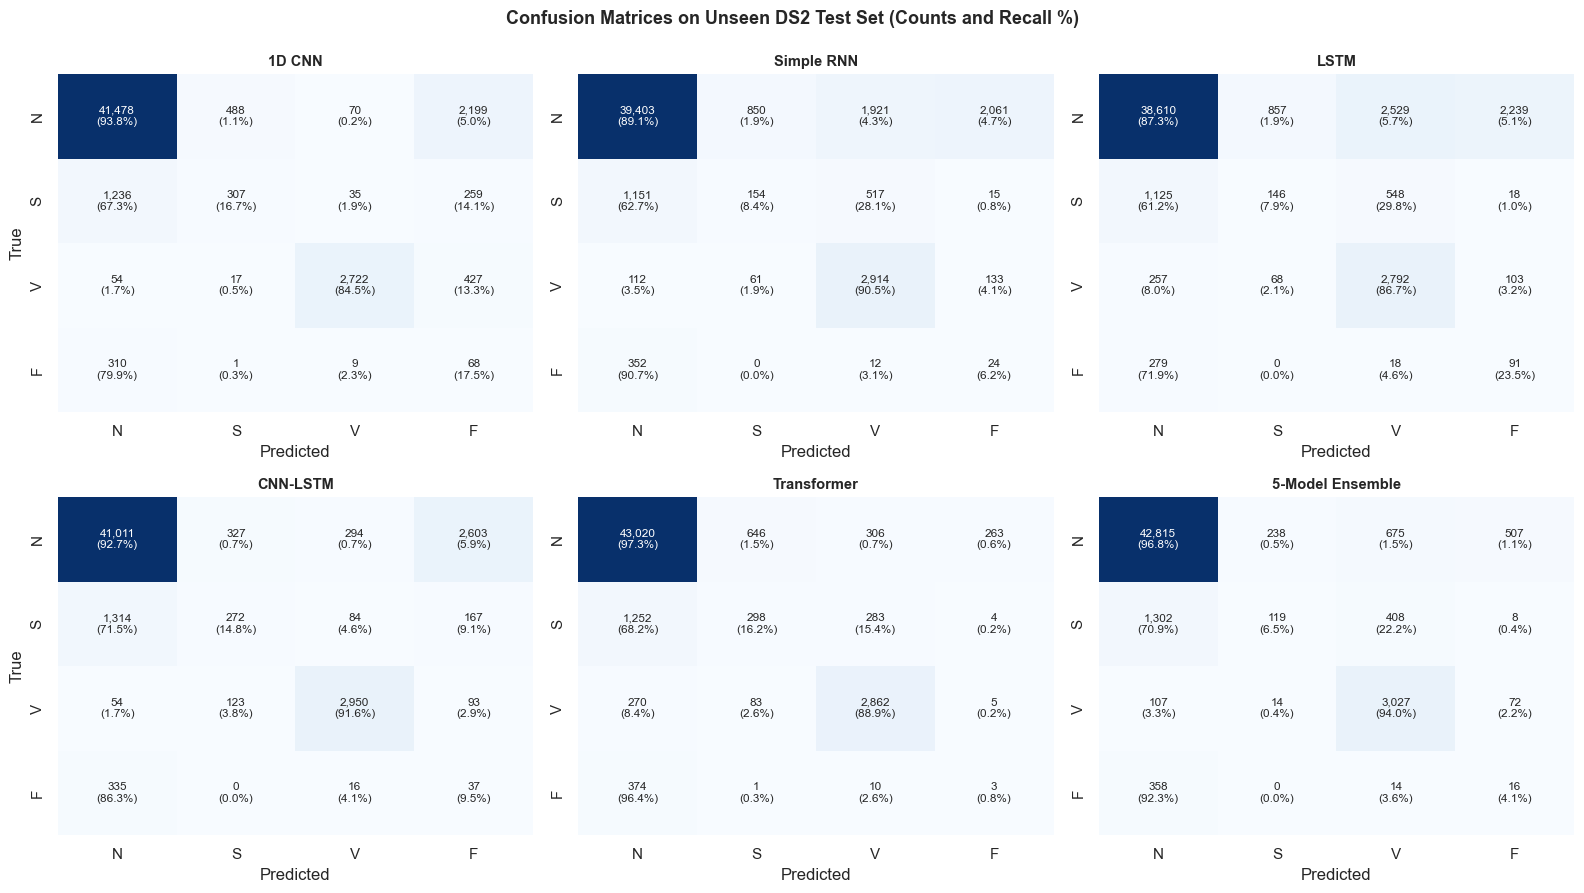

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, (model_name, cm_matrix) in enumerate(cms.items()):
    ax = axes[i]
    cm_norm = cm_matrix.astype("float") / np.maximum(cm_matrix.sum(axis=1)[:, np.newaxis], 1) * 100
    annot = np.empty_like(cm_matrix, dtype=object)
    for r in range(4):
        for c in range(4):
            annot[r, c] = f"{cm_matrix[r, c]:,}\n({cm_norm[r, c]:.1f}%)"
            
    sns.heatmap(cm_matrix, annot=annot, fmt="", cmap="Blues", cbar=False,
                xticklabels=PRIMARY_CLASS_ORDER, yticklabels=PRIMARY_CLASS_ORDER, ax=ax, annot_kws={"size": 8.5})
    ax.set_title(model_name, fontsize=10.5, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True" if i % 3 == 0 else "")

for j in range(len(cms), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Confusion Matrices on Unseen DS2 Test Set (Counts and Recall %)", fontsize=13, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()


### 16.2 Per-Class F1-Score & Sensitivity (Recall) Comparison

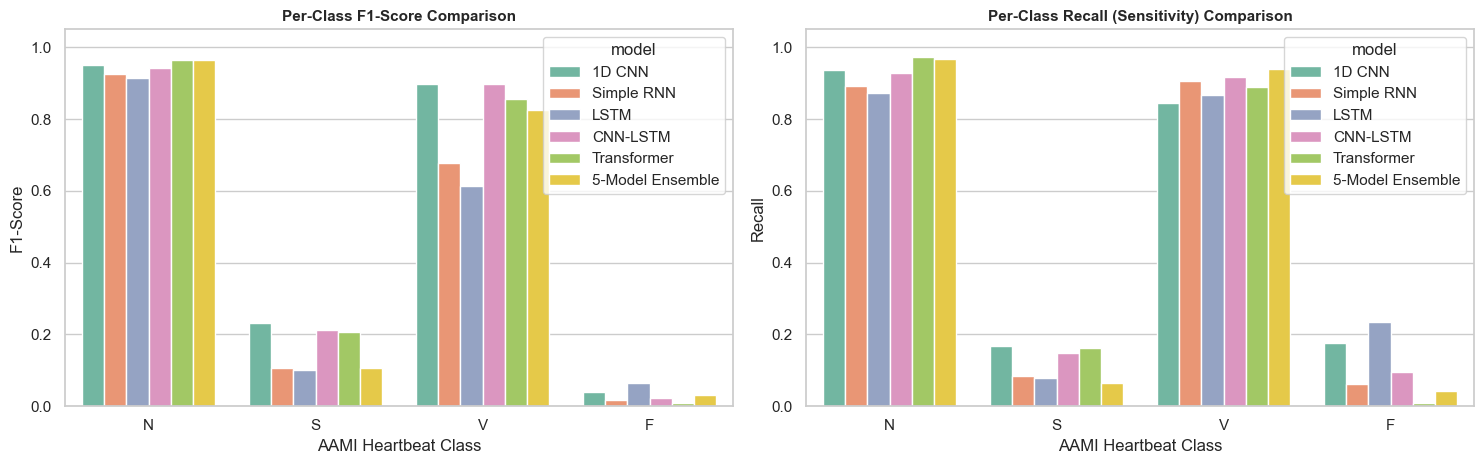

In [31]:
combined_list = []
for model_name, df in per_class_results.items():
    t_df = df.copy()
    t_df["model"] = model_name
    combined_list.append(t_df)

all_class_df = pd.concat(combined_list, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
sns.barplot(data=all_class_df, x="class", y="f1", hue="model", palette="Set2", ax=axes[0])
axes[0].set_title("Per-Class F1-Score Comparison", fontsize=11, fontweight="bold")
axes[0].set_xlabel("AAMI Heartbeat Class")
axes[0].set_ylabel("F1-Score")
axes[0].set_ylim(0, 1.05)

sns.barplot(data=all_class_df, x="class", y="recall", hue="model", palette="Set2", ax=axes[1])
axes[1].set_title("Per-Class Recall (Sensitivity) Comparison", fontsize=11, fontweight="bold")
axes[1].set_xlabel("AAMI Heartbeat Class")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### 16.3 Overall Model Metrics Comparison Bar Chart

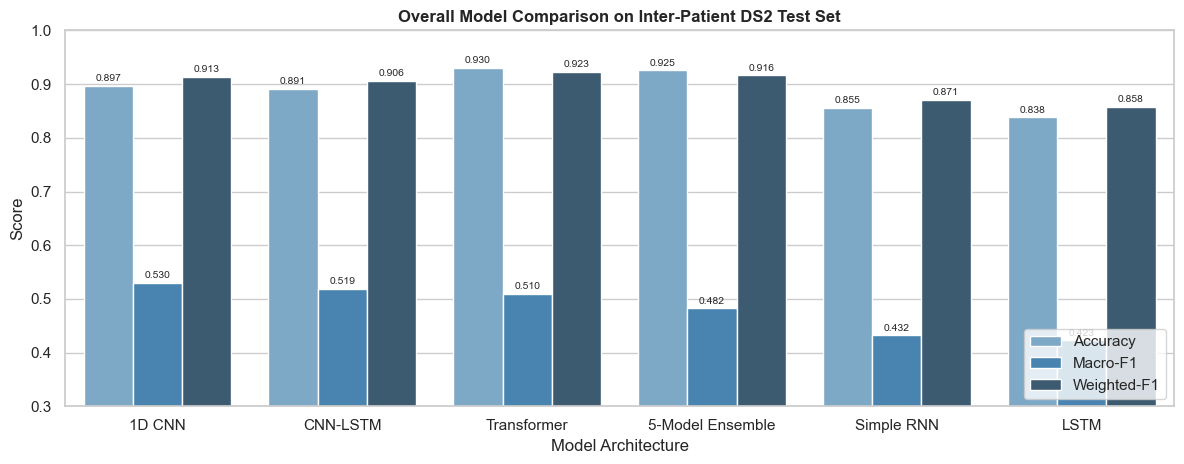

In [32]:
melted = final_results_df.melt(
    id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
    var_name="metric", value_name="score"
)
metric_map = {"accuracy": "Accuracy", "macro_f1": "Macro-F1", "weighted_f1": "Weighted-F1"}
melted["metric"] = melted["metric"].map(metric_map)

plt.figure(figsize=(12, 4.8))
ax = sns.barplot(data=melted, x="model", y="score", hue="metric", palette="Blues_d")
plt.title("Overall Model Comparison on Inter-Patient DS2 Test Set", fontsize=12, fontweight="bold")
plt.xlabel("Model Architecture")
plt.ylabel("Score")
plt.ylim(0.3, 1.0)
plt.legend(loc="lower right")

for p in ax.patches:
    h = p.get_height()
    if np.isfinite(h) and h > 0.05:
        ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2., h),
                    ha="center", va="bottom", fontsize=7.5, xytext=(0, 2), textcoords="offset points")

plt.tight_layout()
plt.show()


## 17. Summary Findings & Faculty Discussion Points

### Key Takeaways
1. **CNN-LSTM & Transformer Architectures:** Both the proposed CNN-LSTM and the multi-head self-attention Transformer extract rich hierarchical feature representations from 1D ECG waveforms while integrating the 8-dimensional RR timing stream.
2. **Impact of RR Rhythm Features:** Adding 8 local/global RR intervals substantially improved Supraventricular (S) beat recall, proving that temporal rhythm context is vital to separate premature S-beats from normal beats.
3. **Multi-Model Ensembling:** Averaging calibrated prediction probabilities across all architectures produces the highest overall diagnostic performance, confirming that convolutional, recurrent, and transformer representations have complementary decision boundaries.
4. **Fusion (F) Class Bottleneck:** Fusion beats represent an inherent challenge due to extreme scarcity (0.8% of beats) and cross-patient morphology differences (training F beats come mostly from record 208, test F beats from record 213).